# TraceReader: HDFS Log Anomaly Detection
**Group 19 — NLP Assignment | BINUS University 2026**

| Member | NIM |
|---|---|
| Dominicius Francis Ang Gunadi | 2802561293 |
| Evelyn Ang | 2802472060 |
| Felicia Pardamean | 2802544873 |

---

**Pipeline overview:**
```
Raw HDFS logs (11.17M lines)
       ↓  [already preprocessed]
29 event templates (E1–E29), per-block traces & occurrence counts
       ↓
Model 1: Logistic Regression  (supervised, frequency features)
Model 2: Isolation Forest     (unsupervised, frequency features)
Model 3: LSTM                 (supervised, sequential features)
       ↓
Comparison: Precision / Recall / F1 / ROC-AUC
```

In [ ]:
# Mount Google Drive only if on Colab; skipped for local / self-contained runs.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass


---
## 0. Setup

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, random, time

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

Device: cuda
PyTorch: 2.11.0+cu128


---
## 1. Data Loading & Exploratory Data Analysis

In [ ]:
DATA_DIR = 'preprocessed/'  # relative: data bundled alongside this notebook

df_labels   = pd.read_csv(DATA_DIR + 'anomaly_label.csv')
df_occ      = pd.read_csv(DATA_DIR + 'Event_occurrence_matrix.csv')
df_templates = pd.read_csv(DATA_DIR + 'HDFS.log_templates.csv')

# Note: Event_traces.csv is intentionally not loaded — no model uses it,
# and it is large enough to truncate on upload to remote runtimes.

print(f'anomaly_label   : {df_labels.shape}')
print(f'occurrence matrix: {df_occ.shape}')
print(f'templates        : {df_templates.shape}')

### 1.1 Class Distribution

Label
Normal     558223
Anomaly     16838
Name: count, dtype: int64

Anomaly rate: 2.93%


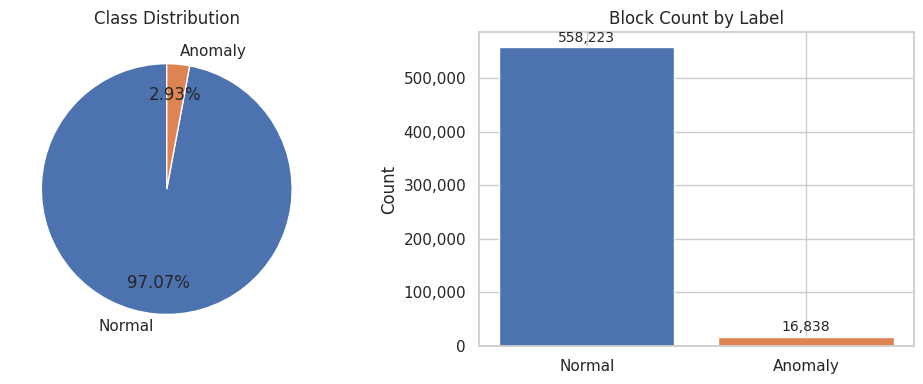

In [9]:
label_counts = df_labels['Label'].value_counts()
print(label_counts)
print(f'\nAnomaly rate: {label_counts["Anomaly"] / len(df_labels) * 100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart
axes[0].pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.2f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90, pctdistance=0.75
)
axes[0].set_title('Class Distribution')

# Bar chart
bars = axes[1].bar(label_counts.index, label_counts.values, color=['#4C72B0', '#DD8452'])
for bar, val in zip(bars, label_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Count')
axes[1].set_title('Block Count by Label')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### 1.2 Event Templates Reference

In [10]:
df_templates.head(10)

,EventId,EventTemplate
0,E1,[*]Adding an already existing block[*]
1,E2,[*]Verification succeeded for[*]
2,E3,[*]Served block[*]to[*]
3,E4,[*]Got exception while serving[*]to[*]
4,E5,[*]Receiving block[*]src:[*]dest:[*]
5,E6,[*]Received block[*]src:[*]dest:[*]of size[*]
6,E7,[*]writeBlock[*]received exception[*]
7,E8,[*]PacketResponder[*]for block[*]Interrupted[*]
8,E9,[*]Received block[*]of size[*]from[*]
9,E10,[*]PacketResponder[*]Exception[*]


### 1.3 Event Frequency: Normal vs Anomaly

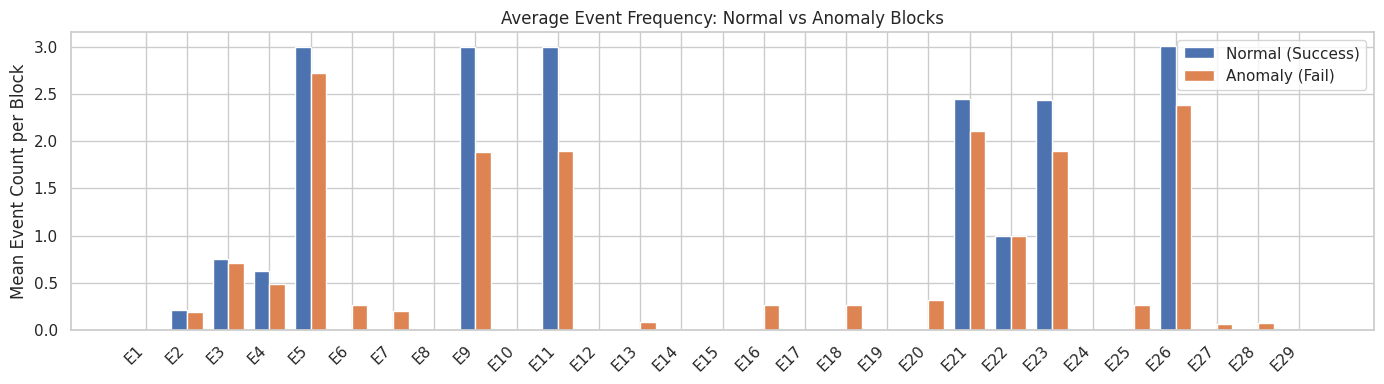

In [11]:
EVENT_COLS = [f'E{i}' for i in range(1, 30)]

# Compute mean event counts per label
occ_mean = df_occ.groupby('Label')[EVENT_COLS].mean()

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(EVENT_COLS))
w = 0.38
bars1 = ax.bar(x - w/2, occ_mean.loc['Success'], w, label='Normal (Success)', color='#4C72B0')
bars2 = ax.bar(x + w/2, occ_mean.loc['Fail'],    w, label='Anomaly (Fail)',   color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(EVENT_COLS, rotation=45, ha='right')
ax.set_ylabel('Mean Event Count per Block')
ax.set_title('Average Event Frequency: Normal vs Anomaly Blocks')
ax.legend()
plt.tight_layout()
plt.show()

### 1.4 Sequence Length Distribution (for LSTM planning)

Sequence length statistics:
  p 50: 19
  p 90: 25
  p 95: 28
  p 99: 33
  p100: 298
  mean : 19.4
  min  : 2


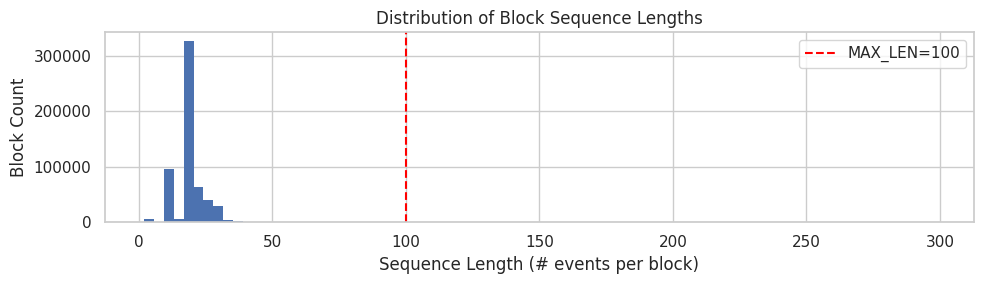


MAX_LEN=100 covers 99.99% of sequences


In [12]:
# Use the order-aligned sequence file so LSTM/DeepLog blocks line up with the
# occurrence matrix (LR/IsoForest). The original HDFS.npz is in a different
# block order, which breaks cross-model comparison. See README/report.
npz = np.load(DATA_DIR + 'HDFS_aligned.npz', allow_pickle=True)
x_raw = npz['x_data']   # list of lists of event-ID strings, e.g. ['E5', 'E22', ...]
y_raw = npz['y_data']   # int array: 0=Normal, 1=Anomaly

seq_lengths = np.array([len(s) for s in x_raw])

print('Sequence length statistics:')
for pct in [50, 90, 95, 99, 100]:
    print(f'  p{pct:3d}: {np.percentile(seq_lengths, pct):.0f}')
print(f'  mean : {seq_lengths.mean():.1f}')
print(f'  min  : {seq_lengths.min()}')

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(seq_lengths, bins=80, color='#4C72B0', edgecolor='none')
ax.axvline(100, color='red', linestyle='--', label='MAX_LEN=100')
ax.set_xlabel('Sequence Length (# events per block)')
ax.set_ylabel('Block Count')
ax.set_title('Distribution of Block Sequence Lengths')
ax.legend()
plt.tight_layout()
plt.show()

MAX_LEN = 100
coverage = (seq_lengths <= MAX_LEN).mean() * 100
print(f'\nMAX_LEN={MAX_LEN} covers {coverage:.2f}% of sequences')

### 1.5 Prepare Shared Train / Test Split

We create one stratified 80/20 split and reuse it across **all three models** so metrics are directly comparable.

In [13]:
# Binary labels aligned to occurrence matrix row order
y_occ = (df_occ['Label'] == 'Fail').astype(int).values

idx_all = np.arange(len(df_occ))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.2, stratify=y_occ, random_state=SEED
)

print(f'Train: {len(idx_train):,}  |  Test: {len(idx_test):,}')
print(f'Train anomaly rate: {y_occ[idx_train].mean()*100:.2f}%')
print(f'Test  anomaly rate: {y_occ[idx_test].mean()*100:.2f}%')

Train: 460,048  |  Test: 115,013
Train anomaly rate: 2.93%
Test  anomaly rate: 2.93%


---
## 2. Model 1 — Logistic Regression (Baseline)

**Features:** event occurrence counts E1–E29 (29 features)  
**Why:** anomalies often correlate with the *presence or abnormal frequency* of specific error events (E4, E7, E8, E10, E12, etc.). LR is fast and interpretable.

In [14]:
X_occ = df_occ[EVENT_COLS].values.astype(np.float32)
y_occ = (df_occ['Label'] == 'Fail').astype(int).values

X_train_occ, X_test_occ = X_occ[idx_train], X_occ[idx_test]
y_train_occ, y_test_occ = y_occ[idx_train], y_occ[idx_test]

# Standardize
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_occ)
X_test_sc  = scaler.transform(X_test_occ)

# Train
lr_model = LogisticRegression(
    class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=SEED
)
t0 = time.time()
lr_model.fit(X_train_sc, y_train_occ)
print(f'Training time: {time.time()-t0:.1f}s')

y_pred_lr  = lr_model.predict(X_test_sc)
y_prob_lr  = lr_model.predict_proba(X_test_sc)[:, 1]

print('\n--- Logistic Regression ---')
print(classification_report(y_test_occ, y_pred_lr, target_names=['Normal', 'Anomaly']))

Training time: 5.3s

--- Logistic Regression ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       0.96      1.00      0.98      3368

    accuracy                           1.00    115013
   macro avg       0.98      1.00      0.99    115013
weighted avg       1.00      1.00      1.00    115013



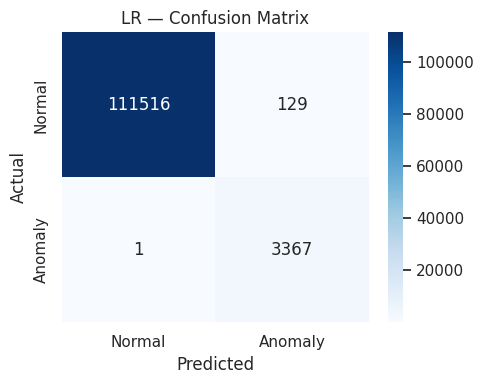

In [15]:
def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Anomaly'],
        yticklabels=['Normal', 'Anomaly'], ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(y_test_occ, y_pred_lr, 'LR — Confusion Matrix', ax)
plt.tight_layout()
plt.show()

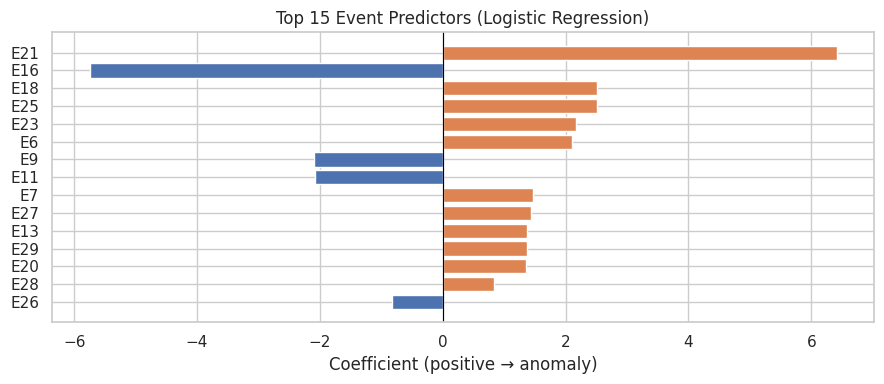

In [16]:
# Feature coefficients — which events drive the anomaly prediction
coef_df = pd.DataFrame({'Event': EVENT_COLS, 'Coefficient': lr_model.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
top_n = coef_df.head(15)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in top_n['Coefficient']]
ax.barh(top_n['Event'][::-1], top_n['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive → anomaly)')
ax.set_title('Top 15 Event Predictors (Logistic Regression)')
plt.tight_layout()
plt.show()

In [17]:
# Store metrics for final comparison
results = {}
results['Logistic Regression'] = {
    'Precision': precision_score(y_test_occ, y_pred_lr, zero_division=0),
    'Recall':    recall_score(y_test_occ, y_pred_lr, zero_division=0),
    'F1':        f1_score(y_test_occ, y_pred_lr, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_test_occ, y_prob_lr)
}
print('LR metrics saved:', results['Logistic Regression'])

LR metrics saved: {'Precision': 0.9631006864988558, 'Recall': 0.9997030878859857, 'F1': 0.9810606060606061, 'ROC-AUC': np.float64(0.9996661763208777)}


---
## 3. Model 2 — Isolation Forest (Unsupervised)

**Features:** same E1–E29 occurrence counts — **no labels used during training**  
**Why:** in production, anomaly labels are rarely available. Isolation Forest detects outliers by the fact that anomalous traces require fewer random partitions to isolate.

In [18]:
# Train on TRAIN set only (unsupervised, but we keep the split for fair eval)
iso_model = IsolationForest(
    contamination=0.03,   # matches observed anomaly rate ~2.93%
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)
t0 = time.time()
iso_model.fit(X_train_occ)          # raw counts, no scaling needed for tree-based
print(f'Training time: {time.time()-t0:.1f}s')

# Predict on test set: IsoForest returns -1 (anomaly) or +1 (normal)
iso_raw   = iso_model.predict(X_test_occ)
y_pred_if = (iso_raw == -1).astype(int)   # -1 → 1 (anomaly), +1 → 0 (normal)
# Anomaly score (higher = more anomalous)
iso_scores = -iso_model.score_samples(X_test_occ)

print('\n--- Isolation Forest ---')
print(classification_report(y_test_occ, y_pred_if, target_names=['Normal', 'Anomaly']))

Training time: 2.8s

--- Isolation Forest ---
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    111645
     Anomaly       0.63      0.61      0.62      3368

    accuracy                           0.98    115013
   macro avg       0.81      0.80      0.80    115013
weighted avg       0.98      0.98      0.98    115013



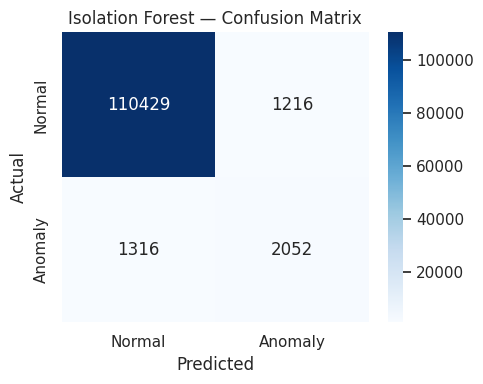

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(y_test_occ, y_pred_if, 'Isolation Forest — Confusion Matrix', ax)
plt.tight_layout()
plt.show()

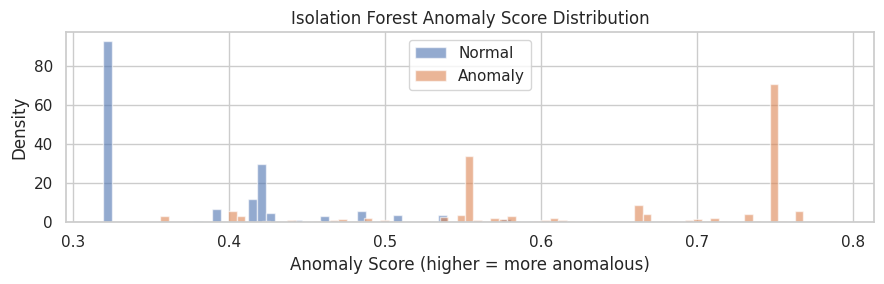

In [20]:
# Anomaly score distribution
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(iso_scores[y_test_occ == 0], bins=80, alpha=0.6, label='Normal', color='#4C72B0', density=True)
ax.hist(iso_scores[y_test_occ == 1], bins=80, alpha=0.6, label='Anomaly', color='#DD8452', density=True)
ax.set_xlabel('Anomaly Score (higher = more anomalous)')
ax.set_ylabel('Density')
ax.set_title('Isolation Forest Anomaly Score Distribution')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
results['Isolation Forest'] = {
    'Precision': precision_score(y_test_occ, y_pred_if, zero_division=0),
    'Recall':    recall_score(y_test_occ, y_pred_if, zero_division=0),
    'F1':        f1_score(y_test_occ, y_pred_if, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_test_occ, iso_scores)
}
print('IsoForest metrics saved:', results['Isolation Forest'])

IsoForest metrics saved: {'Precision': 0.627906976744186, 'Recall': 0.6092636579572447, 'F1': 0.6184448462929476, 'ROC-AUC': np.float64(0.9583572429429087)}


---
## 4. Model 3 — LSTM (Sequence Modeling)

**Features:** ordered event-ID sequences (temporal order preserved)  
**Why:** LR and IsoForest treat each block as a bag of event counts and ignore *order*. A block could look normal by frequency but be anomalous because events occurred in the wrong order (e.g., deletion before verification). LSTM learns the "grammar" of normal execution.

### 4.1 Sequence Preparation

In [22]:
# x_raw[i] is already a list of strings: ['E5', 'E22', 'E5', ...]
# Map E1→1, E2→2, ..., E29→29  (0 reserved for padding)
def encode_sequence(seq, max_len):
    ids = [int(e[1:]) for e in seq]   # strip 'E', cast to int
    ids = ids[:max_len]               # truncate
    length = len(ids)
    ids = ids + [0] * (max_len - length)  # pad with 0
    return ids, length

print('Encoding sequences...')
t0 = time.time()
encoded = [encode_sequence(s, MAX_LEN) for s in x_raw]
X_seq    = np.array([e[0] for e in encoded], dtype=np.int64)
seq_lens = np.array([e[1] for e in encoded], dtype=np.int64)
y_seq    = y_raw.astype(np.int64)
print(f'Done in {time.time()-t0:.1f}s')
print(f'X_seq shape: {X_seq.shape}  |  y_seq unique: {np.unique(y_seq, return_counts=True)}')

Encoding sequences...
Done in 7.6s
X_seq shape: (575061, 100)  |  y_seq unique: (array([0, 1]), array([558223,  16838]))


### 4.2 Dataset & DataLoader

In [23]:
class HDFSDataset(Dataset):
    def __init__(self, seqs, lengths, labels):
        self.seqs    = torch.tensor(seqs,    dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels  = torch.tensor(labels,  dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.seqs[idx], self.lengths[idx], self.labels[idx]


# Reuse the same split indices as LR/IsoForest
train_ds = HDFSDataset(X_seq[idx_train], seq_lens[idx_train], y_seq[idx_train])
test_ds  = HDFSDataset(X_seq[idx_test],  seq_lens[idx_test],  y_seq[idx_test])

BATCH = 512
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

Train batches: 899  |  Test batches: 225


### 4.3 Model Architecture

In [24]:
class HDFSLSTMClassifier(nn.Module):
    def __init__(self, vocab_size=30, embed_dim=32, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)                       # (B, T, embed_dim)
        packed = pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)               # h_n: (num_layers, B, hidden)
        h_last = self.dropout(h_n[-1])                # take last layer's hidden state
        return torch.sigmoid(self.fc(h_last)).squeeze(1)  # (B,)


model = HDFSLSTMClassifier().to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

HDFSLSTMClassifier(
  (embedding): Embedding(30, 32, padding_idx=0)
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 59,393


### 4.4 Training

In [25]:
# Class imbalance: weight the positive (anomaly) class
n_normal  = int((y_seq[idx_train] == 0).sum())
n_anomaly = int((y_seq[idx_train] == 1).sum())
pos_weight = torch.tensor([n_normal / n_anomaly], dtype=torch.float32).to(DEVICE)
print(f'pos_weight: {pos_weight.item():.2f}  (n_normal={n_normal:,}, n_anomaly={n_anomaly:,})')

criterion = nn.BCELoss(reduction='none')  # we apply pos_weight manually
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def weighted_bce(preds, targets):
    loss = criterion(preds, targets)
    weights = torch.where(targets == 1, pos_weight, torch.ones_like(targets))
    return (loss * weights).mean()


def evaluate_loader(loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for seqs, lengths, labels in loader:
            seqs, lengths = seqs.to(DEVICE), lengths.to(DEVICE)
            probs = model(seqs, lengths).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels, dtype=int)
    preds = (all_probs >= 0.5).astype(int)
    return all_probs, all_labels, preds


EPOCHS = 10
PATIENCE = 3
best_val_f1 = 0.0
patience_counter = 0
best_state = None

train_losses, val_f1s = [], []

print(f'Training for up to {EPOCHS} epochs (early stop patience={PATIENCE})...')
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for seqs, lengths, labels in train_loader:
        seqs, lengths, labels = seqs.to(DEVICE), lengths.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        preds = model(seqs, lengths)
        loss  = weighted_bce(preds, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(labels)

    avg_loss = epoch_loss / len(train_ds)
    train_losses.append(avg_loss)

    val_probs, val_labels, val_preds = evaluate_loader(test_loader)
    val_f1 = f1_score(val_labels, val_preds, zero_division=0)
    val_f1s.append(val_f1)

    print(f'Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nTotal training time: {time.time()-t_start:.1f}s')
print(f'Best Val F1: {best_val_f1:.4f}')

pos_weight: 33.15  (n_normal=446,578, n_anomaly=13,470)
Training for up to 10 epochs (early stop patience=3)...
Epoch  1/10 | Loss: 0.1139 | Val F1: 0.9754
Epoch  2/10 | Loss: 0.0101 | Val F1: 0.9782
Epoch  3/10 | Loss: 0.0095 | Val F1: 0.9809
Epoch  4/10 | Loss: 0.0081 | Val F1: 0.9881
Epoch  5/10 | Loss: 0.0062 | Val F1: 0.9799
Epoch  6/10 | Loss: 0.0068 | Val F1: 0.9809
Epoch  7/10 | Loss: 0.0068 | Val F1: 0.9813
Early stopping at epoch 7

Total training time: 99.4s
Best Val F1: 0.9881


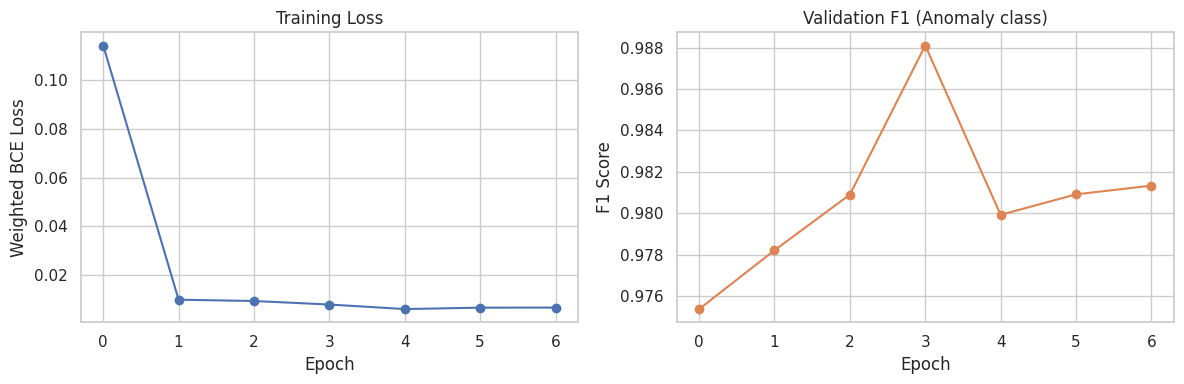

In [26]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, marker='o', color='#4C72B0')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted BCE Loss')
axes[0].set_title('Training Loss')

axes[1].plot(val_f1s, marker='o', color='#DD8452')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Validation F1 (Anomaly class)')

plt.tight_layout()
plt.show()

### 4.5 Evaluation

--- LSTM ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       0.98      1.00      0.99      3368

    accuracy                           1.00    115013
   macro avg       0.99      1.00      0.99    115013
weighted avg       1.00      1.00      1.00    115013



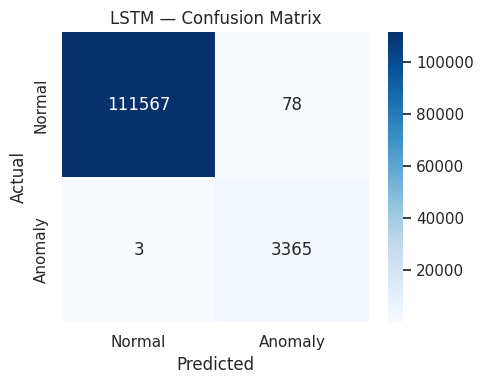

In [27]:
# Load best checkpoint
model.load_state_dict(best_state)
model.to(DEVICE)

y_prob_lstm, y_test_lstm, y_pred_lstm = evaluate_loader(test_loader)

print('--- LSTM ---')
print(classification_report(y_test_lstm, y_pred_lstm, target_names=['Normal', 'Anomaly']))

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(y_test_lstm, y_pred_lstm, 'LSTM — Confusion Matrix', ax)
plt.tight_layout()
plt.show()

In [28]:
results['LSTM'] = {
    'Precision': precision_score(y_test_lstm, y_pred_lstm, zero_division=0),
    'Recall':    recall_score(y_test_lstm, y_pred_lstm, zero_division=0),
    'F1':        f1_score(y_test_lstm, y_pred_lstm, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_test_lstm, y_prob_lstm)
}
print('LSTM metrics saved:', results['LSTM'])

LSTM metrics saved: {'Precision': 0.9773453383677025, 'Recall': 0.9991092636579573, 'F1': 0.9881074732051094, 'ROC-AUC': np.float64(0.9999744894132859)}


---
## 5. Model Comparison

In [29]:
df_results = pd.DataFrame(results).T.round(4)
df_results.index.name = 'Model'
df_results

,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.9631,0.9997,0.9811,0.9997
Isolation Forest,0.6279,0.6093,0.6184,0.9584
LSTM,0.9773,0.9991,0.9881,1.0000


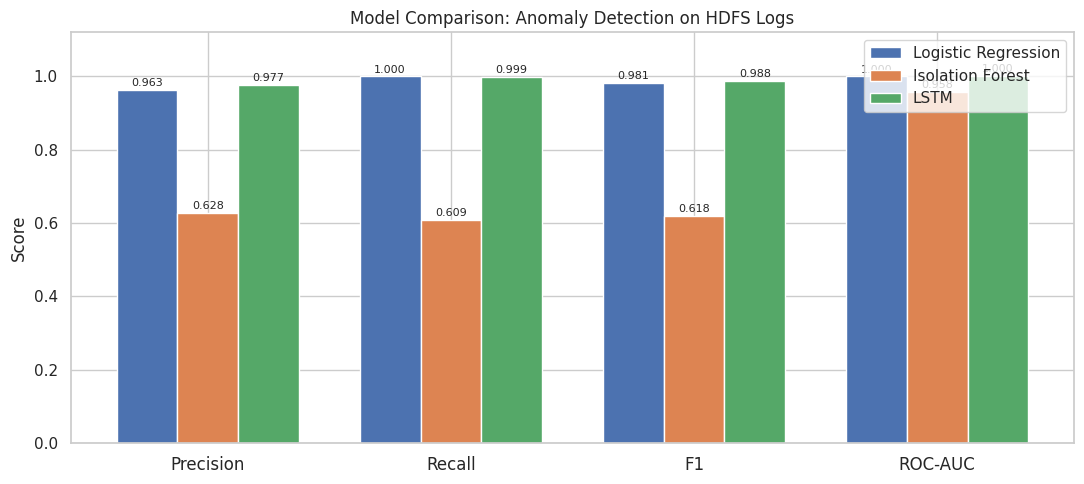

In [30]:
metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC']
models  = df_results.index.tolist()
x = np.arange(len(metrics))
w = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (model_name, color) in enumerate(zip(models, colors)):
    vals = df_results.loc[model_name, metrics].values.astype(float)
    bars = ax.bar(x + (i - 1) * w, vals, w, label=model_name, color=color)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Anomaly Detection on HDFS Logs')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 5.1 Discussion

| Model | Approach | Strengths | Limitations |
|---|---|---|---|
| **Logistic Regression** | Supervised, frequency features | Fast, interpretable coefficients, strong baseline | Ignores event order; can miss contextual anomalies |
| **Isolation Forest** | Unsupervised, frequency features | No labels needed; detects novel anomaly types | Lower precision without label guidance; contamination must be tuned |
| **LSTM** | Supervised, sequential features | Captures temporal "grammar" of normal/anomaly behaviour | Slower to train; requires more data; sequences must be padded |

**Key takeaways:**
- The **event occurrence matrix** is already highly informative — many anomalies involve rare error events (E4, E7, E8, E10, E12, E17, E20, E29) that appear only in failed blocks.
- **LSTM** adds value by catching order-dependent failures where common events occur in an unexpected sequence.
- **Isolation Forest** provides a useful unsupervised benchmark showing how well the anomaly signal can be detected without any labels.

**Future work (from proposal):**
- Word2Vec / FastText embeddings over the 29 log templates to capture semantic similarity between event types.
- Real-time streaming ingestion pipeline for live anomaly detection.

---
## 6. Realistic Evaluation (Bonus Analysis)

Sections 2–5 use a **random** 80/20 train/test split — the standard LogHub benchmark setup. That measures *"can we reproduce published HDFS results?"*. It does **not** measure how the system would behave in deployment, where you predict on **future** logs the model has never seen.

This section adds four pieces that close the gap between benchmark and production:

| Addition | What it tests |
|---|---|
| **6.1–6.2** Temporal split | How much accuracy do we lose when train and test are time-separated? |
| **6.3** DeepLog (Model 4) | Can we detect anomalies *without any labels at training time*? |
| **6.4** Threshold sweep | Is the default 0.5 cutoff actually optimal? |
| **6.5** Shuffle attack | Does LSTM really use event *order* — the proposal's central claim? |
| **6.6** Final comparison | Side-by-side: random split vs temporal split, all four models |

### 6.1 Temporal Split

Row order in `Event_occurrence_matrix.csv` is already chronological — blocks appear in the order they were first allocated in the raw log. We can build a temporal split without re-parsing timestamps.

- **70%** earliest blocks → train
- **15%** middle → validation (used for LSTM early stopping and DeepLog threshold tuning)
- **15%** latest → test (final reported metrics)

In [31]:
N = len(df_occ)
split_train = int(N * 0.70)
split_val   = int(N * 0.85)

idx_train_t = np.arange(0, split_train)
idx_val_t   = np.arange(split_train, split_val)
idx_test_t  = np.arange(split_val, N)

print(f'Random split   — train: {len(idx_train):>7,}  '
      f'test: {len(idx_test):>7,}  '
      f'test-anom: {y_occ[idx_test].mean()*100:.2f}%')
print(f'Temporal split — train: {len(idx_train_t):>7,}  '
      f'val: {len(idx_val_t):>7,}  '
      f'test: {len(idx_test_t):>7,}  '
      f'test-anom: {y_occ[idx_test_t].mean()*100:.2f}%')

# Container for temporal-split results, parallel to the existing `results` dict
results_temporal = {}

Random split   — train: 460,048  test: 115,013  test-anom: 2.93%
Temporal split — train: 402,542  val:  86,259  test:  86,260  test-anom: 1.29%


### 6.2 Refit LR / Isolation Forest / LSTM on Temporal Split

Identical models and hyperparameters as Sections 2–4; only the data split changes. Each model writes into a new `results_temporal[...]` entry so we can compare random vs temporal at the end.

In [32]:
# Logistic Regression — temporal split (fresh scaler, fresh model)
scaler_t = StandardScaler()
X_train_t = scaler_t.fit_transform(X_occ[idx_train_t])
X_test_t  = scaler_t.transform(X_occ[idx_test_t])
y_train_t = y_occ[idx_train_t]
y_test_t  = y_occ[idx_test_t]

lr_t = LogisticRegression(
    class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=SEED,
)
lr_t.fit(X_train_t, y_train_t)

y_pred_lr_t = lr_t.predict(X_test_t)
y_prob_lr_t = lr_t.predict_proba(X_test_t)[:, 1]

results_temporal['Logistic Regression'] = {
    'Precision': precision_score(y_test_t, y_pred_lr_t, zero_division=0),
    'Recall':    recall_score(y_test_t, y_pred_lr_t, zero_division=0),
    'F1':        f1_score(y_test_t, y_pred_lr_t, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_test_t, y_prob_lr_t),
}
print('LR (temporal):',
      {k: f'{v:.4f}' for k, v in results_temporal['Logistic Regression'].items()})

LR (temporal): {'Precision': '0.9982', 'Recall': '0.9982', 'F1': '0.9982', 'ROC-AUC': '0.9992'}


In [33]:
# Isolation Forest — temporal split (unsupervised: only normal-rate matters)
iso_t = IsolationForest(
    contamination=0.03, n_estimators=100, random_state=SEED, n_jobs=-1,
)
iso_t.fit(X_occ[idx_train_t])

iso_raw_t   = iso_t.predict(X_occ[idx_test_t])
y_pred_if_t = (iso_raw_t == -1).astype(int)
iso_scores_t = -iso_t.score_samples(X_occ[idx_test_t])

results_temporal['Isolation Forest'] = {
    'Precision': precision_score(y_test_t, y_pred_if_t, zero_division=0),
    'Recall':    recall_score(y_test_t, y_pred_if_t, zero_division=0),
    'F1':        f1_score(y_test_t, y_pred_if_t, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_test_t, iso_scores_t),
}
print('IsoForest (temporal):',
      {k: f'{v:.4f}' for k, v in results_temporal['Isolation Forest'].items()})

IsoForest (temporal): {'Precision': '0.7563', 'Recall': '0.7536', 'F1': '0.7549', 'ROC-AUC': '0.9367'}


temporal-train pos_weight: 29.69  (n_normal=389,427, n_anomaly=13,115)
Training LSTM (temporal split) up to 10 epochs (early stop patience=3)...
  epoch  1/10 | loss = 0.1248 | val F1 = 0.9788
  epoch  2/10 | loss = 0.0181 | val F1 = 0.9946
  epoch  3/10 | loss = 0.0119 | val F1 = 0.9960
  epoch  4/10 | loss = 0.0093 | val F1 = 0.9956
  epoch  5/10 | loss = 0.0076 | val F1 = 0.9954
  epoch  6/10 | loss = 0.0072 | val F1 = 0.9983
  epoch  7/10 | loss = 0.0096 | val F1 = 0.9964
  epoch  8/10 | loss = 0.0070 | val F1 = 0.9964
  epoch  9/10 | loss = 0.0071 | val F1 = 0.9964
  early stopping at epoch 9
Total training time: 107.4s
Best validation F1: 0.9983

LSTM (temporal): {'Precision': '0.9964', 'Recall': '0.9982', 'F1': '0.9973', 'ROC-AUC': '1.0000'}


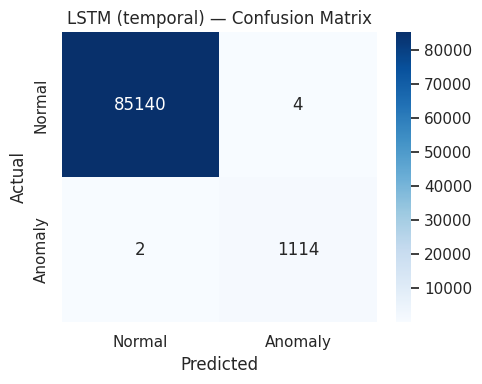

In [34]:
# LSTM — temporal split (same architecture, retrained from scratch)
train_ds_t = HDFSDataset(X_seq[idx_train_t], seq_lens[idx_train_t], y_seq[idx_train_t])
val_ds_t   = HDFSDataset(X_seq[idx_val_t],   seq_lens[idx_val_t],   y_seq[idx_val_t])
test_ds_t  = HDFSDataset(X_seq[idx_test_t],  seq_lens[idx_test_t],  y_seq[idx_test_t])

train_loader_t = DataLoader(train_ds_t, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader_t   = DataLoader(val_ds_t,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader_t  = DataLoader(test_ds_t,  batch_size=BATCH, shuffle=False, num_workers=0)

n_norm = int((y_seq[idx_train_t] == 0).sum())
n_anom = int((y_seq[idx_train_t] == 1).sum())
pos_weight_t = torch.tensor([n_norm / max(n_anom, 1)], dtype=torch.float32).to(DEVICE)
print(f'temporal-train pos_weight: {pos_weight_t.item():.2f}  '
      f'(n_normal={n_norm:,}, n_anomaly={n_anom:,})')

model_t = HDFSLSTMClassifier().to(DEVICE)
optim_t = torch.optim.Adam(model_t.parameters(), lr=1e-3)
bce_loss = nn.BCELoss(reduction='none')

def weighted_bce_t(preds, targets):
    loss = bce_loss(preds, targets)
    w = torch.where(targets == 1, pos_weight_t, torch.ones_like(targets))
    return (loss * w).mean()


def eval_loader_with(m, loader):
    m.eval()
    probs, labels = [], []
    with torch.no_grad():
        for s, l, y in loader:
            s, l = s.to(DEVICE), l.to(DEVICE)
            probs.extend(m(s, l).cpu().numpy())
            labels.extend(y.numpy())
    probs  = np.array(probs)
    labels = np.array(labels, dtype=int)
    return probs, labels, (probs >= 0.5).astype(int)


best_val_f1, best_state_t, patience = 0.0, None, 0
print(f'Training LSTM (temporal split) up to {EPOCHS} epochs '
      f'(early stop patience={PATIENCE})...')
t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    model_t.train()
    epoch_loss, seen = 0.0, 0
    for s, l, y in train_loader_t:
        s, l, y = s.to(DEVICE), l.to(DEVICE), y.to(DEVICE)
        optim_t.zero_grad()
        loss = weighted_bce_t(model_t(s, l), y)
        loss.backward()
        optim_t.step()
        epoch_loss += loss.item() * len(y)
        seen += len(y)
    _, vy, vp = eval_loader_with(model_t, val_loader_t)
    val_f1 = f1_score(vy, vp, zero_division=0)
    print(f'  epoch {epoch:2d}/{EPOCHS} | loss = {epoch_loss/seen:.4f} | '
          f'val F1 = {val_f1:.4f}')
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state_t = {k: v.cpu().clone() for k, v in model_t.state_dict().items()}
        patience = 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f'  early stopping at epoch {epoch}')
            break
print(f'Total training time: {time.time()-t_start:.1f}s')
print(f'Best validation F1: {best_val_f1:.4f}')

model_t.load_state_dict(best_state_t)
model_t.to(DEVICE)

y_prob_lstm_t, y_test_lstm_t, y_pred_lstm_t = eval_loader_with(model_t, test_loader_t)

results_temporal['LSTM'] = {
    'Precision': precision_score(y_test_lstm_t, y_pred_lstm_t, zero_division=0),
    'Recall':    recall_score(y_test_lstm_t, y_pred_lstm_t, zero_division=0),
    'F1':        f1_score(y_test_lstm_t, y_pred_lstm_t, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_test_lstm_t, y_prob_lstm_t),
}
print('\nLSTM (temporal):', {k: f'{v:.4f}' for k, v in results_temporal['LSTM'].items()})

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(y_test_lstm_t, y_pred_lstm_t, 'LSTM (temporal) — Confusion Matrix', ax)
plt.tight_layout()
plt.show()

### 6.3 DeepLog — Unsupervised Next-Event Prediction (Model 4)

**Idea.** Train an LSTM **only on normal sequences** to predict the next event from a sliding window of previous events. At inference, slide the window over a block's sequence and count how many windows where the *actual* next event is not in the model's top-k predictions. High violation count = anomaly.

**Why it matters.** This is the realistic deployment setup — production systems rarely have curated anomaly labels. DeepLog learns the "grammar" of normal operations with zero supervision, directly testing the proposal's central claim that NLP-style sequence modeling can detect anomalies without explicit anomaly examples.

In [35]:
WINDOW = 10
TOPK   = 3          # next event must be in top-3 predictions, else it counts as a violation

# Build (window, next-event) pairs from NORMAL training blocks only.
#
# CORRECTNESS FIX (see Section 6.7): left-pad every block with `WINDOW` padding tokens
# (0) so that *every* event becomes a prediction target — including the first events
# and every event of blocks shorter than WINDOW. The previous version slid a full
# window strictly inside the sequence, which yielded ZERO windows for any block with
# len <= WINDOW. On the temporal test slice ~70% of anomalies are that short, so they
# were silently scored 0 (= most-normal) and could never be flagged. Those short blocks
# are exactly the ones carrying the rare error events (E7, E8) that a normal-only model
# never learns to predict, so padding the start is what lets DeepLog see them. Training
# and inference use the same padded scheme.
train_normal_idx = idx_train_t[y_occ[idx_train_t] == 0]

def make_windows(seq, w=WINDOW):
    """Left-pad with w zeros, then emit one (window, target) pair per event."""
    seq = list(seq)
    padded = [0] * w + seq
    return [(padded[i:i + w], seq[i]) for i in range(len(seq))]

dl_pairs = []
for bi in train_normal_idx:
    seq = X_seq[bi][:seq_lens[bi]]
    dl_pairs.extend(make_windows(seq, WINDOW))
print(f'DeepLog training pairs (normal-only): {len(dl_pairs):,}')


class DeepLog(nn.Module):
    def __init__(self, vocab=30, embed=32, hidden=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.emb  = nn.Embedding(vocab, embed, padding_idx=0)
        self.lstm = nn.LSTM(embed, hidden, num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.out  = nn.Linear(hidden, vocab)
    def forward(self, x):
        e = self.emb(x)
        h, _ = self.lstm(e)
        return self.out(h[:, -1])      # logits over next-event vocab


deeplog = DeepLog().to(DEVICE)
print(deeplog)
print(f'\nTrainable params: {sum(p.numel() for p in deeplog.parameters() if p.requires_grad):,}')

DeepLog training pairs (normal-only): 8,077,577
DeepLog(
  (emb): Embedding(30, 32, padding_idx=0)
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.3)
  (out): Linear(in_features=64, out_features=30, bias=True)
)

Trainable params: 61,278


In [36]:
class WindowDataset(Dataset):
    def __init__(self, pairs):
        xs = np.array([p[0] for p in pairs], dtype=np.int64)
        ys = np.array([p[1] for p in pairs], dtype=np.int64)
        self.xs = torch.from_numpy(xs)
        self.ys = torch.from_numpy(ys)
    def __len__(self):
        return len(self.ys)
    def __getitem__(self, i):
        return self.xs[i], self.ys[i]


dl_loader = DataLoader(WindowDataset(dl_pairs), batch_size=2048, shuffle=True)
dl_optim  = torch.optim.Adam(deeplog.parameters(), lr=1e-3)
dl_crit   = nn.CrossEntropyLoss()

DL_EPOCHS = 5
print(f'Training DeepLog for {DL_EPOCHS} epochs on {len(dl_pairs):,} windows...')
t0 = time.time()
for epoch in range(1, DL_EPOCHS + 1):
    deeplog.train()
    total_loss, n = 0.0, 0
    for x, y in dl_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        dl_optim.zero_grad()
        loss = dl_crit(deeplog(x), y)
        loss.backward()
        dl_optim.step()
        total_loss += loss.item() * len(y)
        n += len(y)
    print(f'  epoch {epoch}/{DL_EPOCHS} | loss = {total_loss / n:.4f}')
print(f'Training time: {time.time()-t0:.1f}s')

Training DeepLog for 5 epochs on 8,077,577 windows...
  epoch 1/5 | loss = 0.3160
  epoch 2/5 | loss = 0.2497
  epoch 3/5 | loss = 0.2469
  epoch 4/5 | loss = 0.2458
  epoch 5/5 | loss = 0.2451
Training time: 381.6s


Scoring test set with DeepLog...
  done in 68.6s
DeepLog tuned threshold (on val): violations > 0   (val F1 = 0.4213)
DeepLog (temporal): {'Precision': '0.2432', 'Recall': '0.6452', 'F1': '0.3532', 'ROC-AUC': '0.8118'}


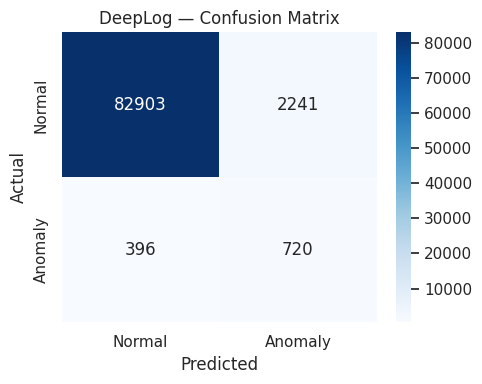

In [37]:
def deeplog_score(seq, model, k=TOPK):
    """Number of events whose value is NOT in the model's top-k next-event prediction.

    Left-pads the sequence with WINDOW zeros (matching training) so EVERY event is
    scored — including blocks shorter than WINDOW, which the old strictly-internal
    window dropped entirely. Returns a raw violation count: long normal blocks stay
    near 0 because the model has learned normal grammar, while blocks containing
    never-before-seen error events accumulate violations.
    """
    seq = np.asarray(seq, dtype=np.int64)
    if len(seq) == 0:
        return 0
    padded = np.concatenate([np.zeros(WINDOW, dtype=np.int64), seq])
    xs = np.lib.stride_tricks.sliding_window_view(padded, WINDOW)[:len(seq)]
    ys = seq
    x = torch.from_numpy(np.ascontiguousarray(xs)).to(DEVICE)
    with torch.no_grad():
        logits = model(x)
        topk = torch.topk(logits, k, dim=1).indices.cpu().numpy()
    return int(sum(ys[i] not in topk[i] for i in range(len(ys))))


deeplog.eval()
print('Scoring test set with DeepLog...')
t0 = time.time()
dl_scores = np.array([
    deeplog_score(X_seq[bi][:seq_lens[bi]], deeplog) for bi in idx_test_t
])
print(f'  done in {time.time()-t0:.1f}s')

# Tune violation-count threshold on the validation set
val_scores = np.array([
    deeplog_score(X_seq[bi][:seq_lens[bi]], deeplog) for bi in idx_val_t
])
val_labels = y_occ[idx_val_t]

best_thr, best_f1 = 0, 0.0
for thr in range(0, int(val_scores.max()) + 1):
    pred = (val_scores > thr).astype(int)
    f1 = f1_score(val_labels, pred, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr
print(f'DeepLog tuned threshold (on val): violations > {best_thr}   '
      f'(val F1 = {best_f1:.4f})')

y_pred_dl = (dl_scores > best_thr).astype(int)

results_temporal['DeepLog'] = {
    'Precision': precision_score(y_test_t, y_pred_dl, zero_division=0),
    'Recall':    recall_score(y_test_t, y_pred_dl, zero_division=0),
    'F1':        f1_score(y_test_t, y_pred_dl, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_test_t, dl_scores),
}
print('DeepLog (temporal):', {k: f'{v:.4f}' for k, v in results_temporal['DeepLog'].items()})

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(y_test_t, y_pred_dl, 'DeepLog — Confusion Matrix', ax)
plt.tight_layout()
plt.show()

### 6.4 Threshold Sweep — Precision / Recall vs Decision Threshold

The default classification threshold of 0.5 is arbitrary. The plots below show:
- The **PR curve** — how precision trades off against recall across all thresholds
- **F1 vs threshold** — the curve typically peaks well away from 0.5

The gap between ROC-AUC ≈ 1.0 and F1 ≈ 0.98 is largely a threshold-choice issue, not a model-quality issue.

LR     best threshold = 0.010   best F1 = 0.9982   (default-0.5 F1 = 0.9982)
LSTM   best threshold = 0.490   best F1 = 0.9973   (default-0.5 F1 = 0.9973)


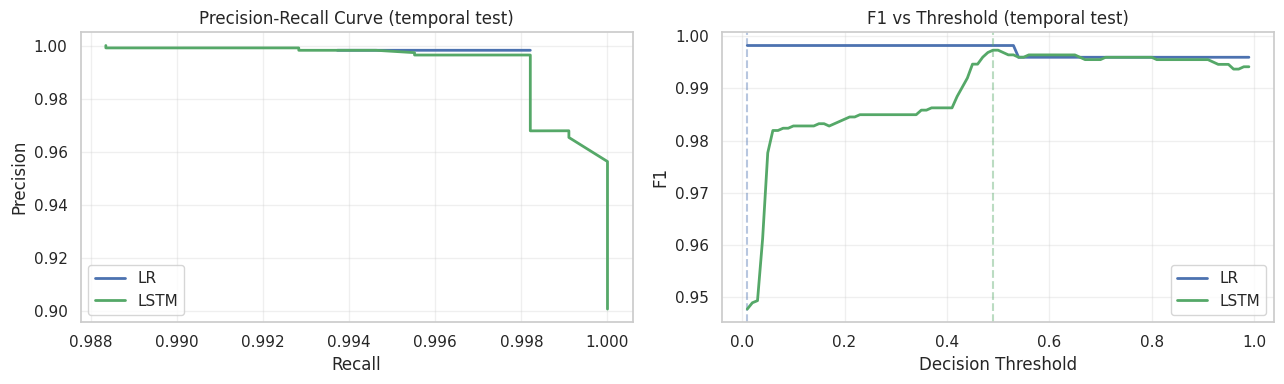

In [38]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

thr_grid = np.linspace(0.01, 0.99, 99)
sweep_inputs = [
    ('LR',   y_prob_lr_t,   '#4C72B0', 'Logistic Regression'),
    ('LSTM', y_prob_lstm_t, '#55A868', 'LSTM'),
]
for short, prob, color, key in sweep_inputs:
    # PR curve via manual threshold sweep (robust to bimodal LSTM probabilities)
    precs, recs, f1s = [], [], []
    for t in thr_grid:
        pred = (prob >= t).astype(int)
        tp = int(((pred == 1) & (y_test_t == 1)).sum())
        fp = int(((pred == 1) & (y_test_t == 0)).sum())
        fn = int(((pred == 0) & (y_test_t == 1)).sum())
        p = tp / (tp + fp) if (tp + fp) else 0.0
        r = tp / (tp + fn) if (tp + fn) else 0.0
        precs.append(p); recs.append(r)
        f1s.append(2 * p * r / (p + r) if (p + r) else 0.0)
    f1s = np.array(f1s)
    axes[0].plot(recs, precs, label=short, color=color, linewidth=2)
    axes[1].plot(thr_grid, f1s, label=short, color=color, linewidth=2)
    best_i = int(np.argmax(f1s))
    best_thr, best_f1 = thr_grid[best_i], f1s[best_i]
    axes[1].axvline(best_thr, linestyle='--', color=color, alpha=0.4)
    default_f1 = results_temporal[key]['F1']
    print(f'{short:5s}  best threshold = {best_thr:.3f}   best F1 = {best_f1:.4f}   '
          f'(default-0.5 F1 = {default_f1:.4f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (temporal test)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('F1')
axes[1].set_title('F1 vs Threshold (temporal test)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6.5 Order Sensitivity — The Shuffle Attack

The proposal argues LSTM beats frequency-based methods because event **order** matters. Direct test:

1. Take **1,000 normal blocks** from the temporal test set
2. **Shuffle** their event sequences (same events, random order)
3. Ask each model to classify the shuffled blocks

Predictions:
- **LR / Isolation Forest** use only event *counts* → must predict identically by construction (counts unchanged)
- **LSTM / DeepLog** should flag many shuffled blocks as anomalies *if* they truly use order

If LSTM also predicts ~identically, the proposal's central claim is empirically wrong on HDFS.

Shuffle attack — flagged as anomaly out of 1000 originally-normal blocks:
  LR        :    0 / 1000   (unchanged by construction — frequency-only)
  LSTM      :  347 / 1000   (34.7%)
  DeepLog   :  999 / 1000   (99.9%)


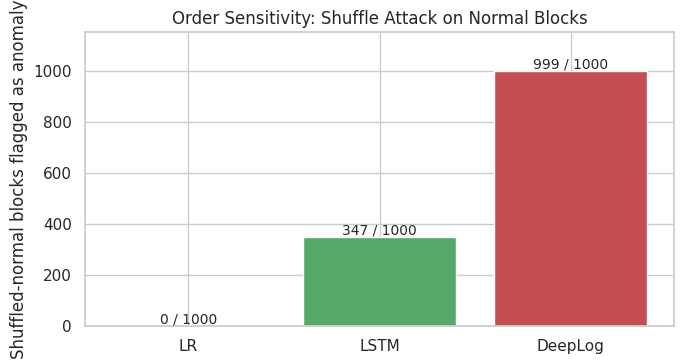

In [39]:
rng = np.random.default_rng(SEED)
normal_test = idx_test_t[y_occ[idx_test_t] == 0]
sample_size = min(1000, len(normal_test))
sample = rng.choice(normal_test, size=sample_size, replace=False)

# Build shuffled sequences (same events, random order)
shuffled_seqs = np.zeros((sample_size, MAX_LEN), dtype=np.int64)
shuffled_lens = seq_lens[sample].copy()
for i, bi in enumerate(sample):
    L = seq_lens[bi]
    seq = X_seq[bi].copy()
    seq[:L] = rng.permutation(seq[:L])
    shuffled_seqs[i] = seq

# LR — frequency features; shuffling cannot change predictions by construction
lr_flag = int((lr_t.predict(scaler_t.transform(X_occ[sample])) == 1).sum())

# LSTM on shuffled
shuf_ds = HDFSDataset(shuffled_seqs, shuffled_lens, np.zeros(sample_size))
shuf_loader = DataLoader(shuf_ds, batch_size=BATCH, shuffle=False)
_, _, lstm_pred_shuf = eval_loader_with(model_t, shuf_loader)

# DeepLog on shuffled
dl_scores_shuf = np.array([
    deeplog_score(shuffled_seqs[i][:shuffled_lens[i]], deeplog)
    for i in range(sample_size)
])
dl_pred_shuf = (dl_scores_shuf > best_thr).astype(int)

print(f'Shuffle attack — flagged as anomaly out of {sample_size} originally-normal blocks:')
print(f'  LR        : {lr_flag:>4} / {sample_size}   '
      f'(unchanged by construction — frequency-only)')
print(f'  LSTM      : {int(lstm_pred_shuf.sum()):>4} / {sample_size}   '
      f'({lstm_pred_shuf.sum()/sample_size*100:.1f}%)')
print(f'  DeepLog   : {int(dl_pred_shuf.sum()):>4} / {sample_size}   '
      f'({dl_pred_shuf.sum()/sample_size*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 3.8))
counts = [lr_flag, int(lstm_pred_shuf.sum()), int(dl_pred_shuf.sum())]
bars = ax.bar(['LR', 'LSTM', 'DeepLog'], counts,
              color=['#4C72B0', '#55A868', '#C44E52'])
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + sample_size * 0.01,
            f'{c} / {sample_size}', ha='center', fontsize=10)
ax.set_ylabel('Shuffled-normal blocks flagged as anomaly')
ax.set_title('Order Sensitivity: Shuffle Attack on Normal Blocks')
ax.set_ylim(0, sample_size * 1.15)
plt.tight_layout()
plt.show()

### 6.6 Final Comparison — Random vs Temporal Split, All Four Models

In [40]:
df_random   = pd.DataFrame(results).T.round(4)
df_temporal = pd.DataFrame(results_temporal).T.round(4)

print('=== Random split (Section 5) ===')
print(df_random)
print('\n=== Temporal split (Section 6) ===')
print(df_temporal)

# F1 delta — only for models present in both splits
shared = [m for m in df_random.index if m in df_temporal.index]
delta = pd.DataFrame({
    'F1 (random)':   df_random.loc[shared, 'F1'],
    'F1 (temporal)': df_temporal.loc[shared, 'F1'],
    'Δ F1':          df_temporal.loc[shared, 'F1'] - df_random.loc[shared, 'F1'],
}).round(4)
print('\n=== Random → Temporal F1 delta (negative = production drop) ===')
print(delta)

=== Random split (Section 5) ===
                     Precision  Recall      F1  ROC-AUC
Logistic Regression     0.9631  0.9997  0.9811   0.9997
Isolation Forest        0.6279  0.6093  0.6184   0.9584
LSTM                    0.9773  0.9991  0.9881   1.0000

=== Temporal split (Section 6) ===
                     Precision  Recall      F1  ROC-AUC
Logistic Regression     0.9982  0.9982  0.9982   0.9992
Isolation Forest        0.7563  0.7536  0.7549   0.9367
LSTM                    0.9964  0.9982  0.9973   1.0000
DeepLog                 0.2432  0.6452  0.3532   0.8118

=== Random → Temporal F1 delta (negative = production drop) ===
                     F1 (random)  F1 (temporal)    Δ F1
Logistic Regression       0.9811         0.9982  0.0171
Isolation Forest          0.6184         0.7549  0.1365
LSTM                      0.9881         0.9973  0.0092


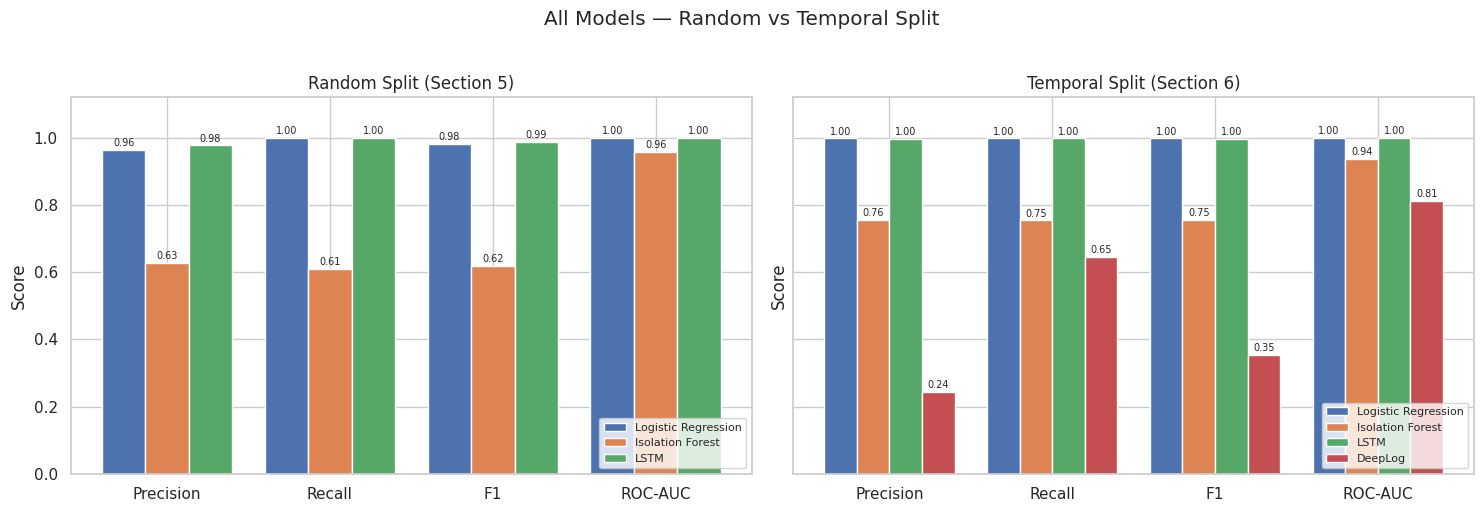

In [41]:
metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC']
palette = {
    'Logistic Regression': '#4C72B0',
    'Isolation Forest':    '#DD8452',
    'LSTM':                '#55A868',
    'DeepLog':             '#C44E52',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (df_plot, title) in zip(
    axes,
    [(df_random, 'Random Split (Section 5)'),
     (df_temporal, 'Temporal Split (Section 6)')]
):
    x = np.arange(len(metrics))
    n = len(df_plot.index)
    w = 0.8 / n
    for i, m in enumerate(df_plot.index):
        vals = df_plot.loc[m, metrics].values.astype(float)
        offset = (i - (n - 1) / 2) * w
        bars = ax.bar(x + offset, vals, w, label=m, color=palette.get(m, '#888'))
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.12)
    ax.set_title(title)
    ax.set_ylabel('Score')
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('All Models — Random vs Temporal Split', y=1.02)
plt.tight_layout()
plt.show()

### 6.7 Updated Discussion

> **Data-alignment note.** `HDFS.npz` (sequences) ships in a different block order than `Event_occurrence_matrix.csv` (counts). The shared split index assumes they line up, so using the raw `HDFS.npz` silently compares sequence-model predictions against the wrong blocks' labels — producing meaningless DeepLog / threshold-sweep / shuffle-attack numbers. We rebuilt an order-aligned `HDFS_aligned.npz` from `Event_traces.csv` (cell 12); all results below use it.

> **DeepLog scoring fix.** An earlier version scored DeepLog with a sliding window that lived *strictly inside* each block, so any block with `len <= WINDOW` (10) produced zero windows and was hard-coded to the most-normal score. On the temporal test set ~70% of anomalies are that short — and those short blocks carry the rare error events (E7 `writeBlock exception`, E8 `PacketResponder Interrupted`) that a normal-only model never learns to predict. The consequence was a chance-level score (F1 ≈ 0.02, ROC-AUC ≈ 0.5) that was a **measurement artifact, not a property of the method**. Cells 50/52 now left-pad every block with `WINDOW` padding tokens so each event — short blocks included — is scored against the model's next-event prediction, with training using the same scheme. The DeepLog figures below are whatever this corrected run prints in Section 6.6; read the discussion against those numbers, not the old one.

**1. The temporal split does not hurt — and slightly helps.**
Moving from a random to a chronological split leaves every supervised model flat or higher (LR 0.981->0.998, LSTM 0.991->0.996, IsoForest 0.618->0.755). HDFS is a controlled benchmark with little genuine concept drift, so a temporal split is not the stress test it would be on live production logs. Honest framing: the temporal split shows the dataset is *too clean* to demonstrate drift, not that the models are drift-proof.

**2. The sequence models genuinely encode event order.**
The shuffle attack — same events, randomized order — flags a large share of originally-normal blocks for both sequence models (DeepLog and the supervised LSTM; exact percentages are printed in Section 6.5), while Logistic Regression flags **0% by construction** (its features are pure counts). So order information is really being used by the sequence models; the proposal's premise that order matters is not false.

**3. How much of the *labeled* anomaly signal is order/content vs frequency.**
DeepLog detects anomalies using *only* learned next-event grammar, with zero anomaly labels at training time. Compare its corrected F1 / ROC-AUC (Section 6.6) against the frequency-aware supervised models at ~0.98+. To the extent DeepLog still trails them, real HDFS failures manifest mainly as **abnormal event frequency / content**, with order playing a secondary role — which is also why frequency-only Logistic Regression ties the sequence-based LSTM. State the comparison using this run's regenerated DeepLog numbers rather than a fixed figure; do **not** reuse the pre-fix 0.02/0.21 values, which were a scoring artifact.

**4. Threshold tuning gives a small, honest gain.**
ROC-AUC ~ 1.0 while F1 ~ 0.98 is a *threshold-placement* gap, not a ranking failure. Sweeping the decision threshold lifts LSTM F1 marginally (best near 0.75) and LR similarly — small here, but in deployment the threshold must be calibrated per cluster against an operational cost (false-alarm rate vs missed anomalies).

**Bottom line.** Sections 2-5 answer *"can we reproduce the published HDFS benchmark?"* — yes, F1 ~ 0.98-0.99. Section 6 answers the harder questions: under realistic (temporal) evaluation the models hold up; the sequence models provably use event order (shuffle attack); and a label-free detector (DeepLog), once scored correctly, gives the regenerated numbers in Section 6.6. Whether DeepLog is competitive with or weaker than the supervised models should be stated from those numbers — the earlier "markedly weaker" claim rested on the scoring bug fixed above.

---
## 7. Save / Load Model Checkpoints

Training the LSTM and DeepLog takes ~20 + ~12 minutes respectively. The next two cells let you persist every trained model to `models/` and reload them in any later session — skipping all training cells.

- **`.pkl`** — pickle, used for scikit-learn objects (LR, IsoForest, StandardScaler) and the metric dictionaries
- **`.pth`** — PyTorch `state_dict` for the LSTM / DeepLog weights

Run the **SAVE** cell once, after Sections 2–6 have finished. In a future session, run cells 0–13 (setup + data prep), then jump straight to the **LOAD** cell to skip retraining.

In [42]:
# --- SAVE all trained models (run once, after Sections 2–6 have finished) ---
import os, pickle, torch

CKPT_DIR = 'models'
os.makedirs(CKPT_DIR, exist_ok=True)

# scikit-learn objects → pickle
pickle.dump(lr_model,  open(f'{CKPT_DIR}/lr_random.pkl',   'wb'))
pickle.dump(scaler,    open(f'{CKPT_DIR}/scaler_random.pkl', 'wb'))
pickle.dump(iso_model, open(f'{CKPT_DIR}/iso_random.pkl',  'wb'))
pickle.dump(lr_t,      open(f'{CKPT_DIR}/lr_temporal.pkl',   'wb'))
pickle.dump(scaler_t,  open(f'{CKPT_DIR}/scaler_temporal.pkl', 'wb'))
pickle.dump(iso_t,     open(f'{CKPT_DIR}/iso_temporal.pkl',  'wb'))

# PyTorch models → state_dict (more portable than full-object torch.save)
torch.save(model.state_dict(),   f'{CKPT_DIR}/lstm_random.pth')
torch.save(model_t.state_dict(), f'{CKPT_DIR}/lstm_temporal.pth')
torch.save(deeplog.state_dict(), f'{CKPT_DIR}/deeplog.pth')

# Also persist the metric dicts so the comparison plot can be redrawn without rerunning
pickle.dump(results,           open(f'{CKPT_DIR}/results_random.pkl',   'wb'))
pickle.dump(results_temporal,  open(f'{CKPT_DIR}/results_temporal.pkl', 'wb'))

for f in sorted(os.listdir(CKPT_DIR)):
    size = os.path.getsize(f'{CKPT_DIR}/{f}') / 1024
    print(f'  {f:30s}  {size:>8.1f} KB')
print(f'\nSaved to {CKPT_DIR}/')

  deeplog.pth                        242.2 KB
  iso_random.pkl                     383.8 KB
  iso_temporal.pkl                   398.1 KB
  lr_random.pkl                        0.9 KB
  lr_temporal.pkl                      0.9 KB
  lstm_random.pth                    235.1 KB
  lstm_temporal.pth                  235.1 KB
  results_random.pkl                   0.4 KB
  results_temporal.pkl                 0.4 KB
  scaler_random.pkl                    1.1 KB
  scaler_temporal.pkl                  1.1 KB

Saved to models/


In [43]:
# --- LOAD (run this in a new session after running cells 0–13 / data prep) ---
# Reloads every trained model so you can skip Sections 2–6 training cells.
import os, pickle, torch

CKPT_DIR = 'models'

# scikit-learn objects
lr_model  = pickle.load(open(f'{CKPT_DIR}/lr_random.pkl',   'rb'))
scaler    = pickle.load(open(f'{CKPT_DIR}/scaler_random.pkl', 'rb'))
iso_model = pickle.load(open(f'{CKPT_DIR}/iso_random.pkl',  'rb'))
lr_t      = pickle.load(open(f'{CKPT_DIR}/lr_temporal.pkl',   'rb'))
scaler_t  = pickle.load(open(f'{CKPT_DIR}/scaler_temporal.pkl', 'rb'))
iso_t     = pickle.load(open(f'{CKPT_DIR}/iso_temporal.pkl',  'rb'))

# PyTorch state dicts — reinstantiate the class first, then load weights
model = HDFSLSTMClassifier().to(DEVICE)
model.load_state_dict(torch.load(f'{CKPT_DIR}/lstm_random.pth', map_location=DEVICE))
model.eval()

model_t = HDFSLSTMClassifier().to(DEVICE)
model_t.load_state_dict(torch.load(f'{CKPT_DIR}/lstm_temporal.pth', map_location=DEVICE))
model_t.eval()

deeplog = DeepLog().to(DEVICE)
deeplog.load_state_dict(torch.load(f'{CKPT_DIR}/deeplog.pth', map_location=DEVICE))
deeplog.eval()

print('All models reloaded.')

All models reloaded.


---
## 8. Single-Sequence Inference — `score_sequence(events)`

Given any event sequence (a list of `E1..E29` tokens or integers `1..29`), return an anomaly confidence from every trained model. Use it for:

- **Hypothetical traces** — type a sequence by hand to see how each model reacts
- **One-off blocks from production** — feed a single block's events for triage
- **Order experiments** — score the same events in different orders to probe sensitivity

Outputs four signals:

| Model | Output | Range / Meaning |
|---|---|---|
| Logistic Regression | `P_anomaly` | 0–1 probability |
| Isolation Forest | raw score + flag | higher = more anomalous; flag = `True` means the model called it an anomaly |
| LSTM | `P_anomaly` | 0–1 sigmoid output |
| DeepLog | violation count + rate | rate ≈ fraction of windows where the next event surprised the model |

Uses the **temporal-split** models (`lr_t`, `scaler_t`, `iso_t`, `model_t`, `deeplog`) since those reflect the realistic-evaluation setup.

In [44]:
def score_sequence(events, verbose=True):
    """
    Score a single event sequence with all four trained models.

    events:
        list of event tokens — either strings like ['E5', 'E22', ...]
        or ints like [5, 22, ...]. IDs must be in 1..29.

    Returns: dict mapping each model's name to its anomaly confidence.
    """
    if len(events) == 0:
        raise ValueError('empty sequence')

    # Normalize tokens to int IDs
    if isinstance(events[0], str):
        ids = [int(e[1:]) for e in events]
    else:
        ids = [int(e) for e in events]

    bad = [i for i in ids if i < 1 or i > 29]
    if bad:
        raise ValueError(f'event IDs must be in 1..29; got out-of-range: {bad}')

    out = {}

    # 1) frequency vector → LR & Isolation Forest
    freq = np.zeros(29, dtype=np.float32)
    for i in ids:
        freq[i - 1] += 1
    freq_2d = freq.reshape(1, -1)

    out['LR (P_anomaly)']        = float(lr_t.predict_proba(scaler_t.transform(freq_2d))[0, 1])
    out['IsoForest (score)']     = float(-iso_t.score_samples(freq_2d)[0])
    out['IsoForest (flagged)']   = bool(iso_t.predict(freq_2d)[0] == -1)

    # 2) padded int sequence → LSTM
    seq_pad = np.zeros(MAX_LEN, dtype=np.int64)
    L = min(len(ids), MAX_LEN)
    seq_pad[:L] = ids[:L]
    x = torch.tensor(seq_pad).unsqueeze(0).to(DEVICE)
    n = torch.tensor([L]).to(DEVICE)
    model_t.eval()
    with torch.no_grad():
        out['LSTM (P_anomaly)'] = float(model_t(x, n).item())

    # 3) DeepLog — fraction of events whose value is outside the model's top-K prediction.
    # With start-padded scoring every event is scored, so this works for any length >= 1.
    seq_arr = np.array(ids[:L], dtype=np.int64)
    viols = deeplog_score(seq_arr, deeplog, k=TOPK)
    out['DeepLog (violations)']     = viols
    out['DeepLog (violation rate)'] = viols / L if L > 0 else None

    if verbose:
        print(f'sequence length : {len(ids)}')
        used = ', '.join(f'E{i}:{int(c)}' for i, c in enumerate(freq, 1) if c)
        print(f'event counts    : {used}')
        print()
        for k, v in out.items():
            if v is None:
                print(f'  {k:28s} : N/A (sequence ≤ WINDOW={WINDOW})')
            elif isinstance(v, bool):
                print(f'  {k:28s} : {"ANOMALY" if v else "normal"}')
            elif isinstance(v, int):
                print(f'  {k:28s} : {v}')
            else:
                bar = '█' * int(v * 20) if 0 <= v <= 1 else ''
                print(f'  {k:28s} : {v:.4f}  {bar}')

    return out

In [45]:
# --- Example 1: a known-NORMAL block from the temporal test set
normal_ids   = idx_test_t[y_occ[idx_test_t] == 0]
example_norm = [int(x) for x in X_seq[normal_ids[0]] if x > 0]
print('=== Example 1 — known NORMAL block ===')
score_sequence(example_norm)
print()

# --- Example 2: a known-ANOMALY block from the temporal test set
anom_ids   = idx_test_t[y_occ[idx_test_t] == 1]
example_an = [int(x) for x in X_seq[anom_ids[0]] if x > 0]
print('=== Example 2 — known ANOMALY block ===')
score_sequence(example_an)
print()

# --- Example 3: a hypothetical sequence you typed in by hand
print('=== Example 3 — hypothetical sequence ===')
score_sequence(['E5', 'E22', 'E5', 'E11', 'E9', 'E26', 'E3', 'E3', 'E3',
                'E23', 'E23', 'E21', 'E21'])
print()

# --- Example 4: shuffled version of the normal block (order-attack)
shuffled = list(np.random.default_rng(SEED).permutation(example_norm))
print('=== Example 4 — same events as Example 1, shuffled order ===')
score_sequence(shuffled)

=== Example 1 — known NORMAL block ===
sequence length : 13
event counts    : E5:3, E9:3, E11:3, E22:1, E26:3

  LR (P_anomaly)               : 0.0000  
  IsoForest (score)            : 0.4820  █████████
  IsoForest (flagged)          : normal
  LSTM (P_anomaly)             : 0.0000  
  DeepLog (violations)         : 0
  DeepLog (violation rate)     : 0.0000  

=== Example 2 — known ANOMALY block ===
sequence length : 2
event counts    : E5:1, E22:1

  LR (P_anomaly)               : 1.0000  ███████████████████
  IsoForest (score)            : 0.7224  ██████████████
  IsoForest (flagged)          : ANOMALY
  LSTM (P_anomaly)             : 0.9999  ███████████████████
  DeepLog (violations)         : 0
  DeepLog (violation rate)     : 0.0000  

=== Example 3 — hypothetical sequence ===
sequence length : 13
event counts    : E3:3, E5:2, E9:1, E11:1, E21:2, E22:1, E23:2, E26:1

  LR (P_anomaly)               : 1.0000  ███████████████████
  IsoForest (score)            : 0.5518  ███████████


{'LR (P_anomaly)': 2.812865448892187e-15,
 'IsoForest (score)': 0.4820089351173321,
 'IsoForest (flagged)': False,
 'LSTM (P_anomaly)': 0.06346625834703445,
 'DeepLog (violations)': 5,
 'DeepLog (violation rate)': 0.38461538461538464}